**Image** **Captioning**

Intalling and Importing the required Libraries

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 21.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 17.0.0 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 17.0.0 which is incompatible.


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.2 MB/s eta 0:00:00


In [ ]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 105.0 MB/s eta 0:00:00


In [ ]:
!pip install transformers[torch]

In [ ]:
!pip install accelerate>=0.21.0 -U

In [ ]:
from google.colab import drive
import os
from matplotlib import pyplot as plt
import pandas as pd
import random
import cv2
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from textwrap import wrap
import pyarrow.parquet as pq

Exploritary Data Analysis

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = '/content/drive/MyDrive/Flikr_dataset/'
img_path = os.path.join(base_path, 'Images')
img_file_names = os.listdir(img_path)
img_file_dir = [os.path.join(img_path, file_name) for file_name in img_file_names]

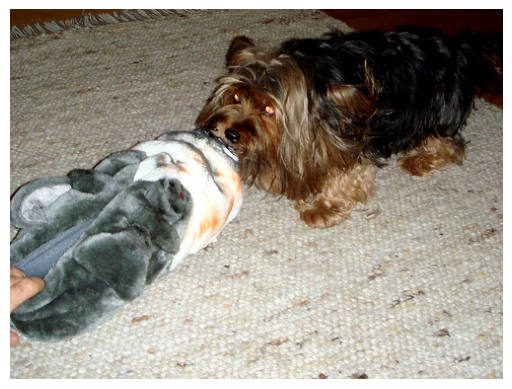

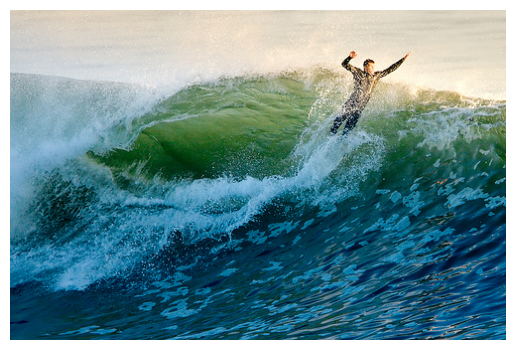

In [ ]:
for i,img in enumerate(random.sample(img_file_dir, 2)):
  img = cv2.imread(img)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

In [ ]:
df_captions = pd.read_csv('/content/drive/MyDrive/Flikr_dataset/captions.txt', sep=',', header=0)
df_captions

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
...,...,...
40450,997722733_0cb5439472.jpg,A man in a pink shirt climbs a rock face
40451,997722733_0cb5439472.jpg,A man is rock climbing high in the air .
40452,997722733_0cb5439472.jpg,A person in a red shirt climbing up a rock fac...
40453,997722733_0cb5439472.jpg,A rock climber in a red shirt .


In [ ]:
print("Number of samples:", len(df_captions))
print("Number of unique image IDs:", df_captions["image"].nunique())
df_captions["caption"] = df_captions["caption"].apply(lambda x: x.lower())
print("Number of unique captions:", df_captions["caption"].nunique())

Number of samples: 40455
Number of unique image IDs: 8091
Number of unique captions: 40170


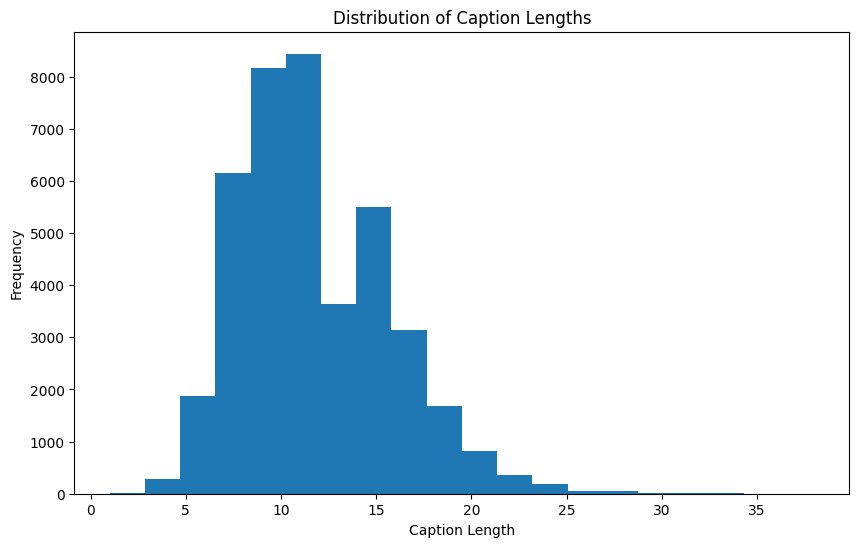

In [ ]:
length_captions = df_captions['caption'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
plt.hist(length_captions, bins=20)
plt.title('Distribution of Caption Lengths')
plt.xlabel('Caption Length')
plt.ylabel('Frequency')
plt.show()

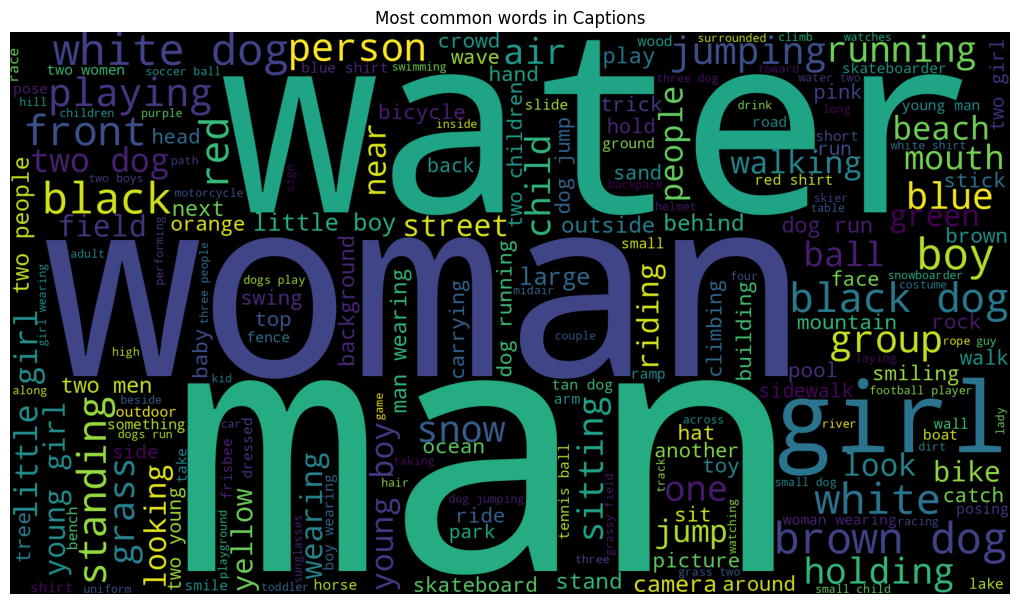

In [ ]:
wordcloud = WordCloud(width=1920,height=1080).generate(" ".join(df_captions.caption))
fig = plt.figure(figsize=(10,10))
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Most common words in Captions')
plt.show()

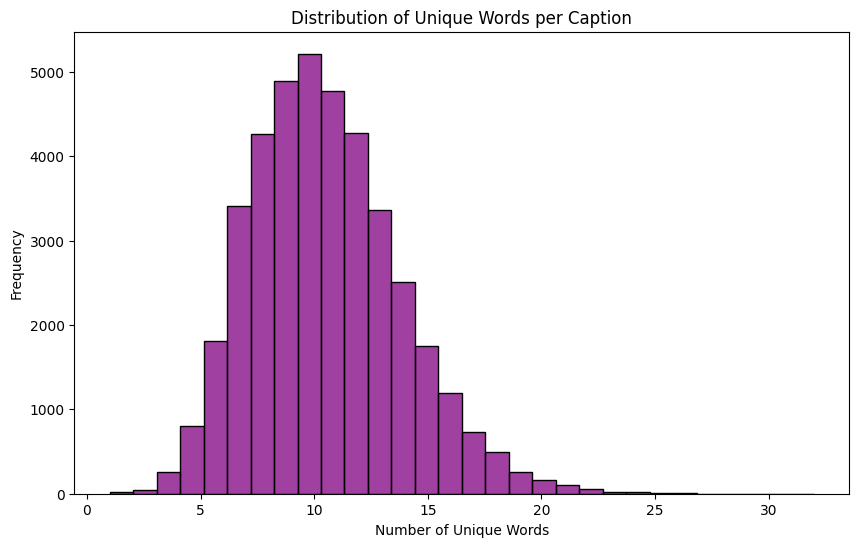

In [ ]:
unique_words_per_caption = [len(set(caption.split())) for caption in df_captions['caption']]

plt.figure(figsize=(10, 6))
sns.histplot(unique_words_per_caption, bins=30, kde=False, color='purple')
plt.title('Distribution of Unique Words per Caption')
plt.xlabel('Number of Unique Words')
plt.ylabel('Frequency')
plt.show()

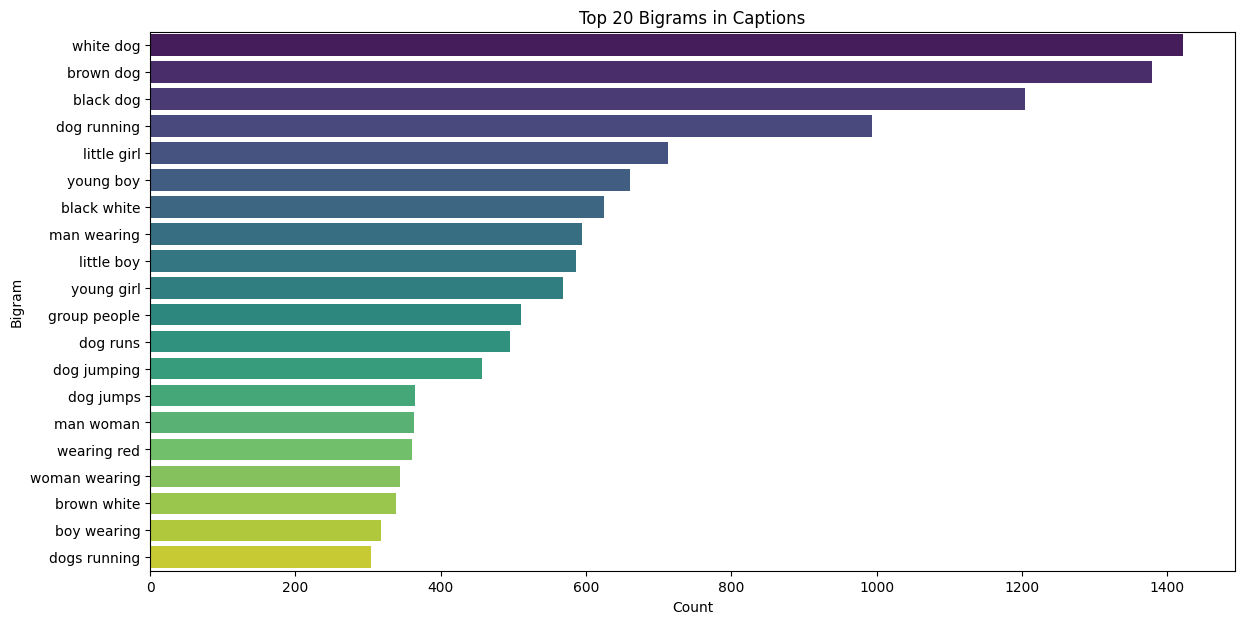

In [ ]:
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words = 'english')
X = vectorizer.fit_transform(df_captions['caption'])

bigram_counts = X.sum(axis=0).A1
bigram_features = vectorizer.get_feature_names_out()


bigram_dist = pd.DataFrame({'bigram': bigram_features, 'count': bigram_counts})
bigram_df = bigram_dist.sort_values(by='count', ascending=False).head(20)

plt.figure(figsize=(14, 7))
sns.barplot(x= 'count', y= 'bigram',data = bigram_df, palette='viridis', hue = 'bigram', legend = False)
plt.title('Top 20 Bigrams in Captions')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

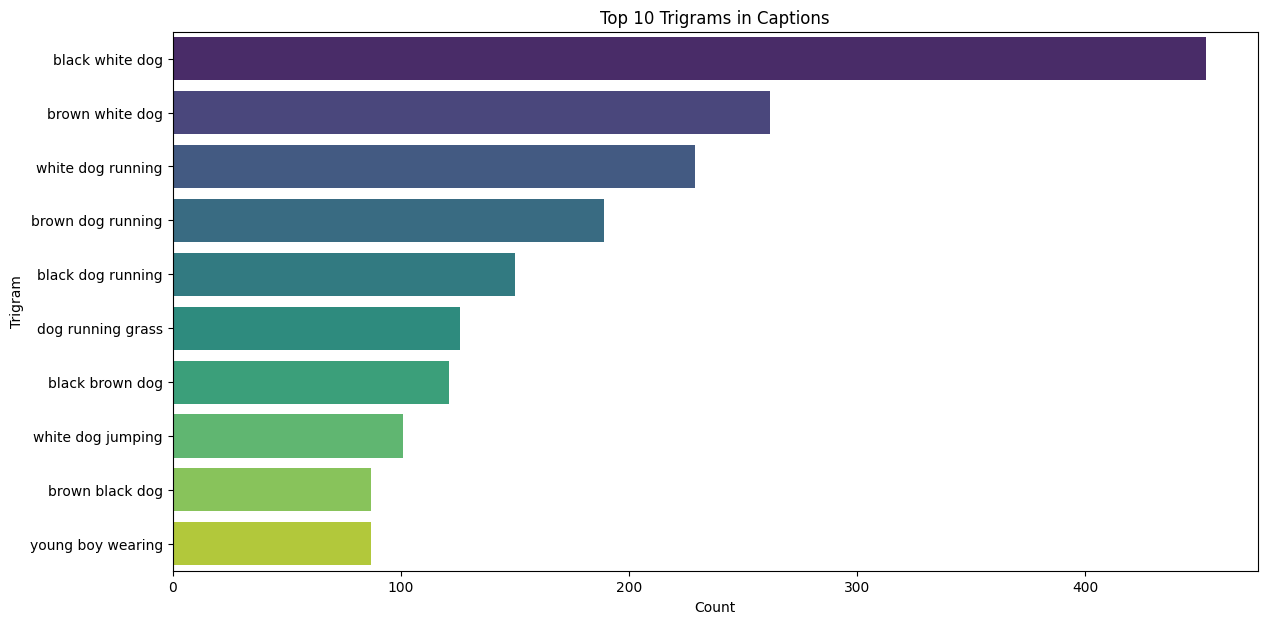

In [ ]:
vectorizer = CountVectorizer(ngram_range=(3, 3), stop_words='english')
Y = vectorizer.fit_transform(df_captions['caption'])

trigram_counts = Y.sum(axis=0).A1
trigram_features = vectorizer.get_feature_names_out()


trigram_dist = pd.DataFrame({'trigram': trigram_features, 'count': trigram_counts})
trigram_df = trigram_dist.sort_values(by='count', ascending=False).head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x= 'count', y= 'trigram',data = trigram_df, palette='viridis', hue = 'trigram', legend = False)
plt.title('Top 10 Trigrams in Captions')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

Image Augmentation

In [ ]:
import albumentations as A

In [ ]:
Augmentaion_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.5)
    ])

In [ ]:
rand_list = random.sample(range(0,500), 50)

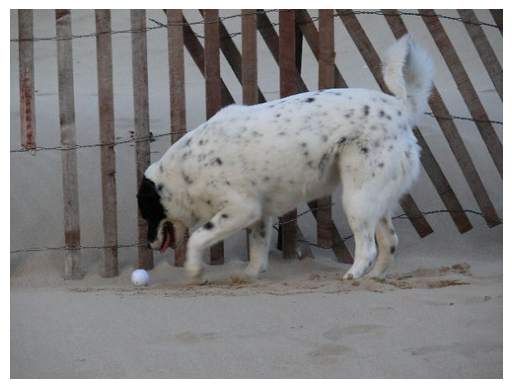

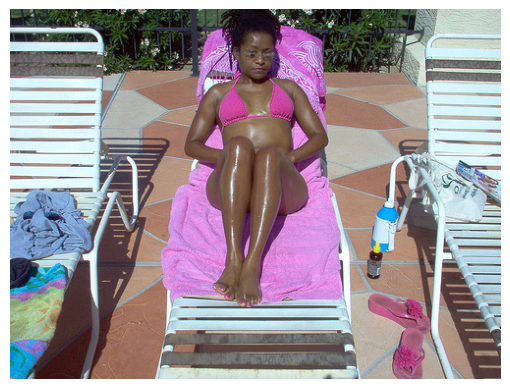

In [ ]:
plt.imshow(cv2.cvtColor(cv2.imread(img_file_dir[rand_list[0]]),cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
plt.imshow(cv2.cvtColor(cv2.imread(img_file_dir[rand_list[3]]),cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
augmented_images = []
for i in rand_list:
  aug = Augmentaion_pipeline(image = cv2.imread(img_file_dir[i]))
  augmented_images.append(aug['image'])

In [ ]:
import numpy as np
def caption_selector(captions):
  unique_words_per_caption = [len(set(caption.split())) for caption in captions]
  return np.array(unique_words_per_caption).argmax()

In [ ]:
aug_image_name = []
aug_caption = []
for i in rand_list:
  aug_image_name.append(f'augmented_{img_file_names[i]}')
  temp = df_captions[df_captions['image']==img_file_names[i]]['caption']
  temp = temp.reset_index(drop=True)
  aug_caption.append(temp[caption_selector(temp)])

In [ ]:
img_count = 1
for i,img in enumerate(augmented_images):
  img_path = os.path.join('/content/drive/MyDrive/Flikr_dataset/aug_images',f'augmented_{img_file_names[rand_list[i]]}')
  cv2.imwrite(img_path, img)
  img_file_dir[rand_list[i]] = img_path
  img_file_names[rand_list[i]] = f'augmented_{img_file_names[rand_list[i]]}'
  img_count += 1
print(img_count)

51


In [ ]:
temp_df = pd.DataFrame({'image':aug_image_name,'caption':aug_caption})
temp_df.head()

,image,caption
0,augmented_477768471_d7cd618fdb.jpg,a dog playing with a golf ball in front of a s...
1,augmented_448916362_17f3f1d0e1.jpg,the white and black dog runs on the field with...
2,augmented_375392855_54d46ed5c8.jpg,a woman skier in yellow and black races down t...
3,augmented_494329594_6e751372a0.jpg,there is a very oiled darker woman on a pink t...
4,augmented_501520507_c86f805ab8.jpg,"there is a man wearing a red shirt , white sho..."


In [ ]:
df_captions = pd.concat([df_captions, temp_df], ignore_index=True)

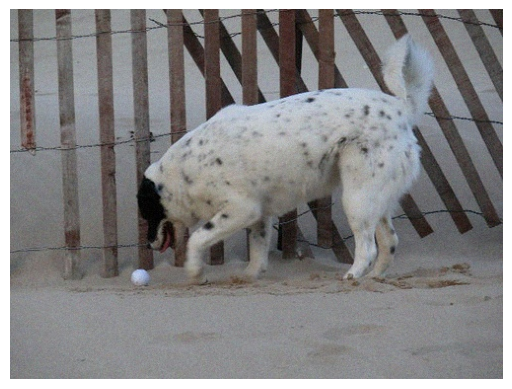

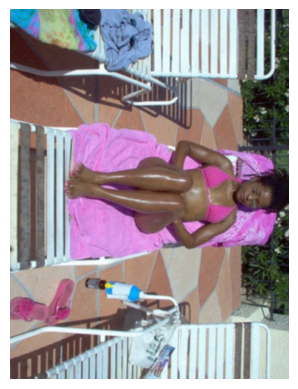

In [ ]:
plt.imshow(cv2.cvtColor(cv2.imread(img_file_dir[rand_list[0]]), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
plt.imshow(cv2.cvtColor(cv2.imread(img_file_dir[rand_list[3]]), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

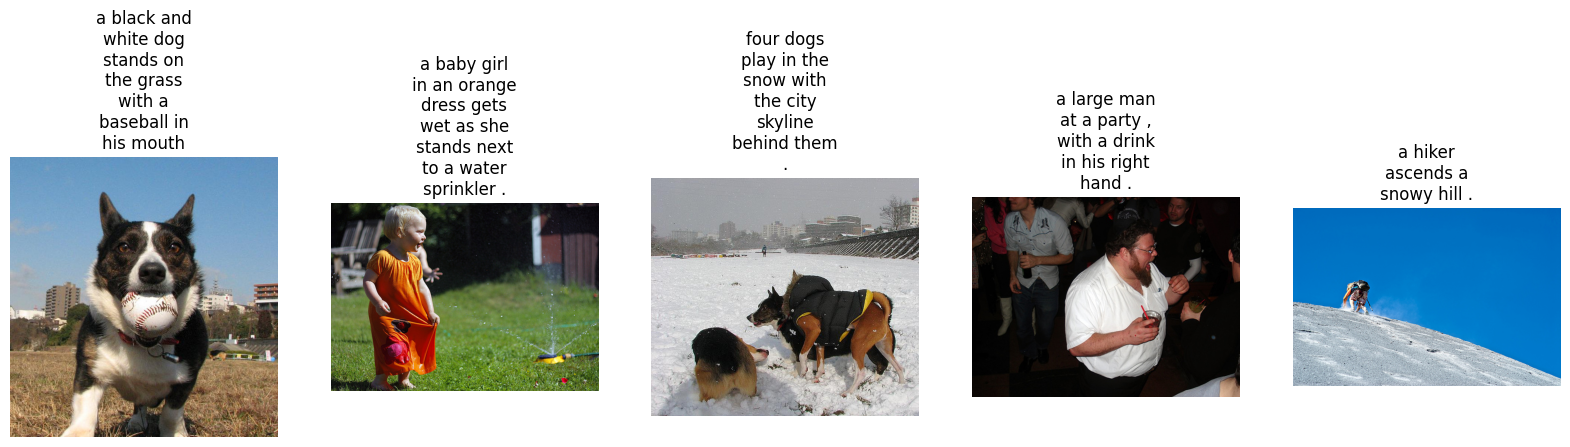

In [ ]:
images = img_file_dir[:5]
plt.figure(figsize=(20, 20))
for i,file in enumerate(img_file_names[:5]):
  ax = plt.subplot(1, len(images), i + 1)
  caption = df_captions[df_captions['image']==file]['caption'].reset_index(drop=True)[0]
  caption = "\n".join(wrap(caption, 12))
  plt.title(caption)
  plt.imshow(cv2.cvtColor(cv2.imread(images[i]),cv2.COLOR_BGR2RGB))
  plt.axis("off")

Image Preprocessing

In [ ]:
from datasets import DatasetDict, Dataset
from PIL import Image

In [ ]:
np_image = {}
for files in img_file_dir[:500]:
  np_image[files]= Image.open(files)

In [ ]:
data = {"image": [], "caption": []}
for i,img in enumerate(img_file_names[:500]):
  if img.startswith('augmented_'):
    img_path = os.path.join(base_path, 'aug_images')
  else:
    img_path = os.path.join(base_path, 'Images')
  data['image'].append(np_image[os.path.join(img_path, img)])
  if img.startswith('augmented'):
    data['caption'].append(df_captions[df_captions['image']==img]['caption'].reset_index(drop=True)[0])
  else:
    data['caption'].append(df_captions[df_captions['image']==img]['caption'].reset_index(drop=True)[random.randrange(0, 5)])

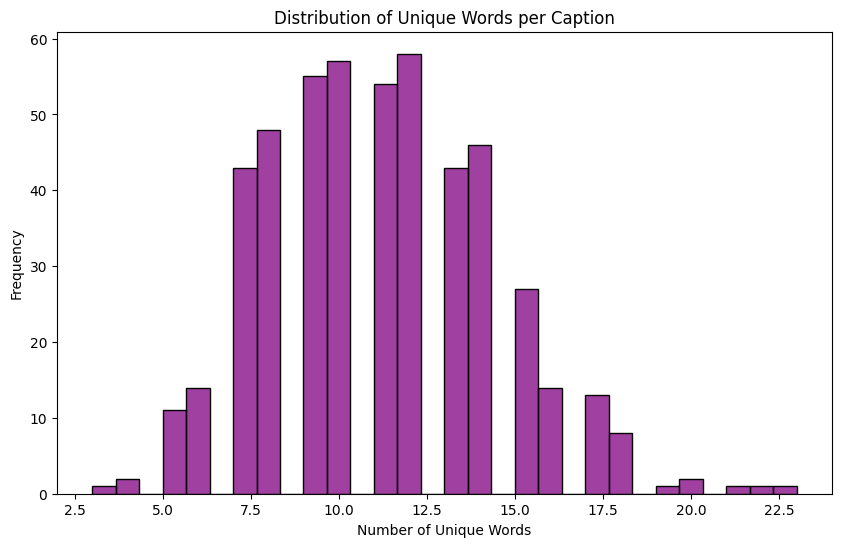

In [ ]:
unique_words_per_caption = [len(set(caption.split())) for caption in data['caption']]

plt.figure(figsize=(10, 6))
sns.histplot(unique_words_per_caption, bins=30, kde=False, color='purple')
plt.title('Distribution of Unique Words per Caption')
plt.xlabel('Number of Unique Words')
plt.ylabel('Frequency')
plt.show()

In [ ]:
dataset = Dataset.from_dict(data)

In [ ]:
train_test_split = dataset.train_test_split(test_size=0.1)
dataset = DatasetDict(train_test_split)

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'caption'],
        num_rows: 450
    })
    test: Dataset({
        features: ['image', 'caption'],
        num_rows: 50
    })
})

In [ ]:
# ds = dataset["train"].train_test_split(test_size=0.1)
train_ds = dataset["train"]
test_ds = dataset["test"]

In [ ]:
from transformers import AutoProcessor

checkpoint = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
def transforms(example_batch):
    images = [x for x in example_batch["image"]]
    captions = [x for x in example_batch["caption"]]
    inputs = processor(images=images, text=captions, padding="max_length")
    inputs.update({"labels": inputs["input_ids"]})
    return inputs


train_ds.set_transform(transforms)
test_ds.set_transform(transforms)

Modelling and Fine-Tunning

In [ ]:
from evaluate import load
import torch

wer = load("wer")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predicted = logits.argmax(-1)
    decoded_labels = processor.batch_decode(labels, skip_special_tokens=True)
    decoded_predictions = processor.batch_decode(predicted, skip_special_tokens=True)
    wer_score = wer.compute(predictions=decoded_predictions, references=decoded_labels)
    return {"wer_score": wer_score}

In [ ]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/2.82k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/707M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [ ]:
from transformers import TrainingArguments, Trainer

model_name = checkpoint.split("/")[1]

training_args = TrainingArguments(
    output_dir=f"/content/drive/MyDrive/new/{model_name}",
    learning_rate=5e-5,
    num_train_epochs=100,
    fp16=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    save_total_limit=3,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    logging_steps=100,
    remove_unused_columns=False,
    label_names=["labels"],
    load_best_model_at_end=True,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:488: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
model.to(device)

GitForCausalLM(
  (git): GitModel(
    (embeddings): GitEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(1024, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (image_encoder): GitVisionModel(
      (vision_model): GitVisionTransformer(
        (embeddings): GitVisionEmbeddings(
          (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
          (position_embedding): Embedding(197, 768)
        )
        (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (encoder): GitVisionEncoder(
          (layers): ModuleList(
            (0-11): 12 x GitVisionEncoderLayer(
              (self_attn): GitVisionAttention(
                (k_proj): Linear(in_features=768, out_features=768, bias=True)
                (v_proj): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Wer Score
100,4.680400,0.295242,3.947935
200,0.067400,0.080764,9.245961
300,0.008400,0.087992,8.933573
400,0.001900,0.090105,8.034111
500,0.001100,0.092638,8.168761
600,0.000800,0.093622,7.669659
700,0.000500,0.095254,7.633752
800,0.000400,0.097005,7.427289
900,0.000400,0.097629,7.518851
1000,0.000400,0.098783,7.667864


TrainOutput(global_step=2800, training_loss=0.1702133403182961, metrics={'train_runtime': 2479.5397, 'train_samples_per_second': 18.149, 'train_steps_per_second': 1.129, 'total_flos': 2.067718478347469e+16, 'train_loss': 0.1702133403182961, 'epoch': 98.24561403508773})

In [ ]:
wer_score = []
for metric in trainer.state.log_history:
  if 'eval_wer_score' in metric:
    wer_score1.append(metric['eval_wer_score'])
avg_wer_score = sum(wer_score)/len(wer_score)
avg_wer_score

6.356501667094127

In [ ]:
eval_loss = []
for metric in trainer.state.log_history:
  if 'eval_loss' in metric:
    eval_loss.append(metric['eval_loss'])
avg_eval_loss = sum(eval_loss)/len(eval_loss)
avg_eval_loss

0.10664703963058335

In [ ]:
trainer.save_model('/content/drive/MyDrive/new/500_model')

**Preprocessing**

In [ ]:
new_df = {'image':[], 'caption':[]}
len_10,len_15,len_20, len_35 = [],[],[],[]

In [ ]:
def caption_diff(length, img):
  if length <= 10:
    len_10.append(img)
  elif length <= 15:
    len_15.append(img)
  elif length <= 20:
    len_20.append(img)
  else:
    len_35.append(img)

In [ ]:
for img in img_file_names:
  temp = df_captions[df_captions['image']==img]['caption'].reset_index(drop=True)
  unique_words_per_caption = [len(set(caption.split())) for caption in temp]
  index = np.array(unique_words_per_caption).argmax()
  length = max(unique_words_per_caption)
  caption_diff(length, img)
  new_df['image'].append(img)
  new_df['caption'].append(temp[index])

In [ ]:
len(len_10), len(len_15), len(len_20), len(len_35)

(511, 5120, 2246, 214)

In [ ]:
img_10 = random.sample(len_10, 100)
img_15 = random.sample(len_15, 150)
img_20 = random.sample(len_20, 150)
img_35 = random.sample(len_35, 50)

In [ ]:
final_img = img_10 + img_15 + img_20 + img_35
len(final_img)

450

In [ ]:
new_df = pd.DataFrame(new_df)

In [ ]:
final_caption = new_df[new_df['image'].isin(final_img)]
df_captions_1 = pd.concat([final_caption, temp_df], ignore_index=True)

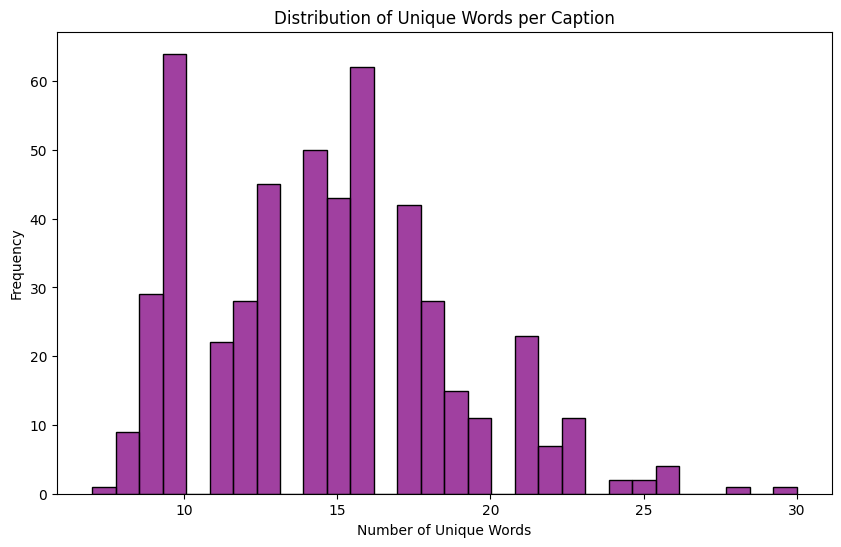

In [ ]:
unique_words_per_caption = [len(set(caption.split())) for caption in df_captions_1['caption']]

plt.figure(figsize=(10, 6))
sns.histplot(unique_words_per_caption, bins=30, kde=False, color='purple')
plt.title('Distribution of Unique Words per Caption')
plt.xlabel('Number of Unique Words')
plt.ylabel('Frequency')
plt.show()

In [ ]:
final_img = df_captions_1['image'].tolist()

In [ ]:
np_image = {}
for img in final_img:
  if img.startswith('augmented_'):
    img_path = os.path.join(base_path, 'aug_images')
  else:
    img_path = os.path.join(base_path, 'Images')
  np_image[img]= Image.open(os.path.join(img_path, img))

In [ ]:
data = {"image": [], "caption": []}
for i,img in enumerate(final_img):
  data['image'].append(np_image[img])
  data['caption'].append(df_captions_1[df_captions_1['image']==img]['caption'].reset_index(drop=True)[0])

In [ ]:
dataset = Dataset.from_dict(data)
train_test_split = dataset.train_test_split(test_size=0.1)
dataset = DatasetDict(train_test_split)
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'caption'],
        num_rows: 450
    })
    test: Dataset({
        features: ['image', 'caption'],
        num_rows: 50
    })
})

In [ ]:
train_ds = dataset["train"]
test_ds = dataset["test"]

train_ds.set_transform(transforms)
test_ds.set_transform(transforms)

In [ ]:
checkpoint = "microsoft/git-base"
model = AutoModelForCausalLM.from_pretrained(checkpoint)

In [ ]:
from transformers import TrainingArguments, Trainer

model_name = checkpoint.split("/")[1]

training_args = TrainingArguments(
    output_dir=f"/content/drive/MyDrive/new/{model_name}",
    learning_rate=5e-5,
    num_train_epochs=100,
    fp16=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    save_total_limit=3,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    logging_steps=100,
    remove_unused_columns=False,
    label_names=["labels"],
    load_best_model_at_end=True,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

device = "cuda" if torch.cuda.is_available() else "cpu"


model.to(device)

trainer.train()

/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:488: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Step,Training Loss,Validation Loss,Wer Score
100,4.695300,0.324874,3.477330
200,0.085100,0.105291,9.453401
300,0.012700,0.110598,8.104534
400,0.003200,0.117905,7.695214
500,0.001400,0.118435,7.831234
600,0.001000,0.120798,7.763224
700,0.000800,0.122472,7.431990
800,0.000600,0.124656,7.206549
900,0.000500,0.126097,7.102015
1000,0.000500,0.127356,6.809824


TrainOutput(global_step=2800, training_loss=0.17169185756971794, metrics={'train_runtime': 2433.6013, 'train_samples_per_second': 18.491, 'train_steps_per_second': 1.151, 'total_flos': 2.067718478347469e+16, 'train_loss': 0.17169185756971794, 'epoch': 98.24561403508773})

In [ ]:
wer_score2 = []
for metric in trainer.state.log_history:
  if 'eval_wer_score' in metric:
    wer_score2.append(metric['eval_wer_score'])
avg_wer_score = sum(wer_score2)/len(wer_score2)
avg_wer_score

6.858717164447644

In [ ]:
eval_loss = []
for metric in trainer.state.log_history:
  if 'eval_loss' in metric:
    eval_loss.append(metric['eval_loss'])
avg_eval_loss = sum(eval_loss)/len(eval_loss)
avg_eval_loss

0.13547323431287492

In [ ]:
trainer.save_model('/content/drive/MyDrive/new/filtered_500_model')

Data Preprocessing

In [ ]:
new_df = {'image':[], 'caption':[]}

In [ ]:
for img in img_file_names:
  temp = df_captions[df_captions['image']==img]['caption'].reset_index(drop=True)
  unique_words_per_caption = [len(set(caption.split())) for caption in temp]
  index = np.array(unique_words_per_caption).argmax()
  length = max(unique_words_per_caption)
  if length >= 8 and length <= 15:
    new_df['image'].append(img)
    new_df['caption'].append(temp[index])

In [ ]:
new_df = pd.DataFrame(new_df)
len(new_df)

5626

In [ ]:
images = random.sample(new_df['image'].tolist(), 450)
new_df = new_df[new_df['image'].isin(images)]

In [ ]:
df_captions_2 = pd.concat([new_df, temp_df], ignore_index=True)

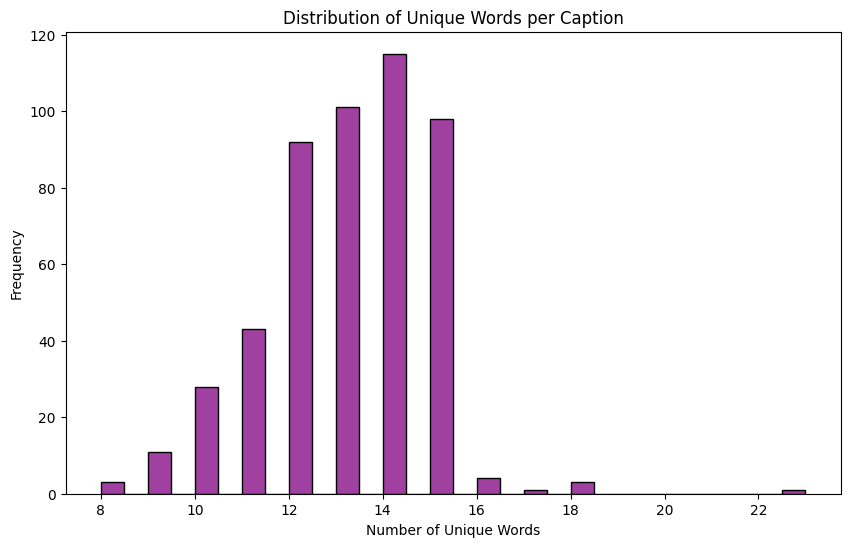

In [ ]:
unique_words_per_caption = [len(set(caption.split())) for caption in df_captions_2['caption']]

plt.figure(figsize=(10, 6))
sns.histplot(unique_words_per_caption, bins=30, kde=False, color='purple')
plt.title('Distribution of Unique Words per Caption')
plt.xlabel('Number of Unique Words')
plt.ylabel('Frequency')
plt.show()

In [ ]:
final_img = df_captions_2['image'].tolist()
np_image = {}
for img in final_img:
  if img.startswith('augmented_'):
    img_path = os.path.join(base_path, 'aug_images')
  else:
    img_path = os.path.join(base_path, 'Images')
  np_image[img]= Image.open(os.path.join(img_path, img))

In [ ]:
data = {"image": [], "caption": []}
for i,img in enumerate(final_img):
  data['image'].append(np_image[img])
  data['caption'].append(df_captions_2[df_captions_2['image']==img]['caption'].reset_index(drop=True)[0])
dataset = Dataset.from_dict(data)
train_test_split = dataset.train_test_split(test_size=0.1)
dataset = DatasetDict(train_test_split)
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'caption'],
        num_rows: 450
    })
    test: Dataset({
        features: ['image', 'caption'],
        num_rows: 50
    })
})

In [ ]:
train_ds = dataset["train"]
test_ds = dataset["test"]

train_ds.set_transform(transforms)
test_ds.set_transform(transforms)

In [ ]:
checkpoint = "microsoft/git-base"
model = AutoModelForCausalLM.from_pretrained(checkpoint)

In [ ]:
from transformers import TrainingArguments, Trainer

model_name = checkpoint.split("/")[1]

training_args = TrainingArguments(
    output_dir=f"/content/drive/MyDrive/new/{model_name}",
    learning_rate=5e-5,
    num_train_epochs=100,
    fp16=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    save_total_limit=3,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    logging_steps=100,
    remove_unused_columns=False,
    label_names=["labels"],
    load_best_model_at_end=True,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

device = "cuda" if torch.cuda.is_available() else "cpu"


model.to(device)

trainer.train()

/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:488: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Step,Training Loss,Validation Loss,Wer Score
100,4.671800,0.308010,8.346763
200,0.076200,0.095157,10.561151
300,0.010100,0.103003,11.785612
400,0.002300,0.108545,11.572662
500,0.001100,0.109837,11.151079
600,0.000800,0.112882,11.014388
700,0.000600,0.114564,10.988489
800,0.000500,0.116454,10.917986
900,0.000400,0.117428,10.247482
1000,0.000400,0.118493,9.372662


TrainOutput(global_step=2800, training_loss=0.17040756542102567, metrics={'train_runtime': 2434.7492, 'train_samples_per_second': 18.482, 'train_steps_per_second': 1.15, 'total_flos': 2.067718478347469e+16, 'train_loss': 0.17040756542102567, 'epoch': 98.24561403508773})

In [ ]:
wer_score3 = []
for metric in trainer.state.log_history:
  if 'eval_wer_score' in metric:
    wer_score3.append(metric['eval_wer_score'])
avg_wer_score = sum(wer_score3)/len(wer_score3)
avg_wer_score

8.627646454265157

In [ ]:
eval_loss = []
for metric in trainer.state.log_history:
  if 'eval_loss' in metric:
    eval_loss.append(metric['eval_loss'])
avg_eval_loss = sum(eval_loss)/len(eval_loss)
avg_eval_loss

0.1263419073075056

In [ ]:
model.save_pretrained('/content/drive/MyDrive/new/filtered_500_model_1')

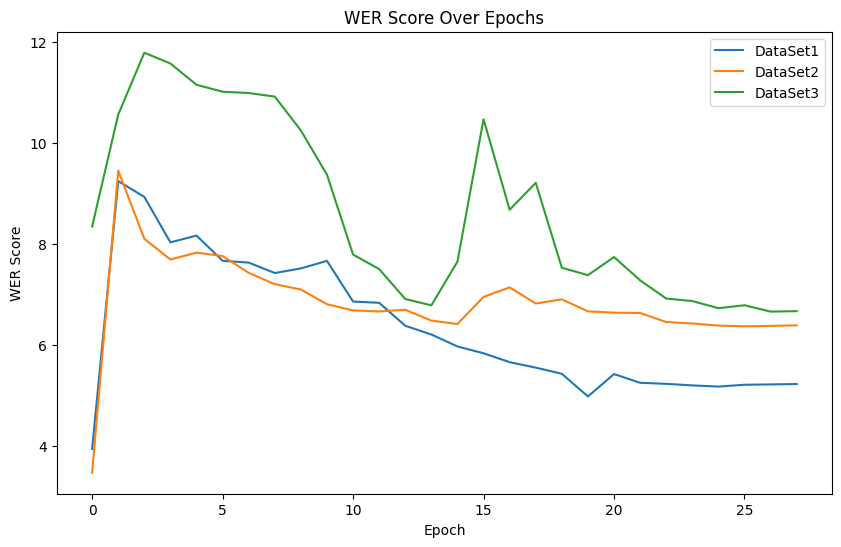

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(wer_score, label='DataSet1')
plt.plot(wer_score2, label='DataSet2')
plt.plot(wer_score3, label='DataSet3')
plt.xlabel('Epoch')
plt.ylabel('WER Score')
plt.title('WER Score Over Epochs')
plt.legend()
plt.show()

In [ ]:
model = AutoModelForCausalLM.from_pretrained('/content/drive/MyDrive/new/500_model')
model1 = AutoModelForCausalLM.from_pretrained('/content/drive/MyDrive/new/filtered_500_model')
model2 = AutoModelForCausalLM.from_pretrained('/content/drive/MyDrive/new/filtered_500_model_1')

In [ ]:
import torch
image = Image.open(img_file_dir[455])

inputs = processor(images=image, return_tensors="pt").to('cpu')
pixel_values = inputs.pixel_values

First 500 images

In [ ]:
generated_ids = model.generate(pixel_values=pixel_values, max_length=50)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
generated_caption

'a child with blue pants and a blue shirt is riding a brown horse.'

Evenely Distributed

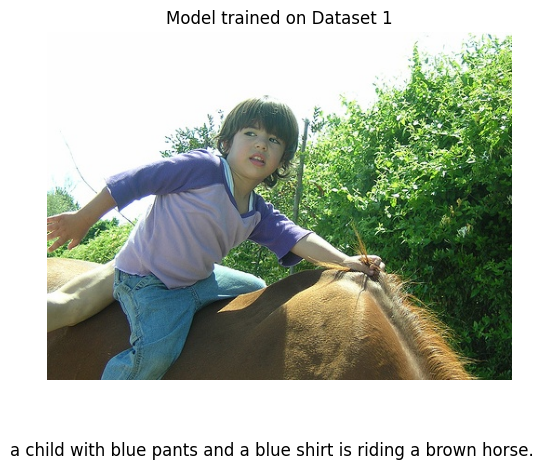

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')  # Hide the axis
plt.subplots_adjust(bottom=0.01)  # Adjust bottom space to fit the caption
plt.figtext(0.5, 0.03, generated_caption, wrap=True, horizontalalignment='center', fontsize=12)  # Place caption under the image
plt.title('Model trained on Dataset 1')
plt.show()

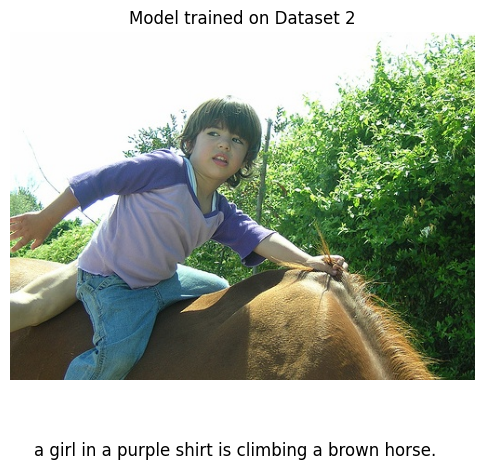

In [ ]:
generated_ids = model1.generate(pixel_values=pixel_values, max_length=50)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
generated_caption
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')  # Hide the axis
plt.subplots_adjust(bottom=0.01)  # Adjust bottom space to fit the caption
plt.figtext(0.5, 0.03, generated_caption, wrap=True, horizontalalignment='center', fontsize=12)  # Place caption under the image
plt.title('Model trained on Dataset 2')
plt.show()

caption length between 8 - 12

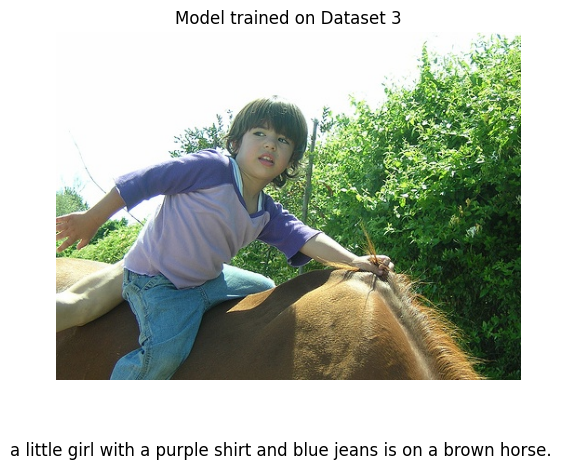

In [ ]:
generated_ids = model2.generate(pixel_values=pixel_values, max_length=50)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
generated_caption
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')  # Hide the axis
plt.subplots_adjust(bottom=0.01)  # Adjust bottom space to fit the caption
plt.figtext(0.5, 0.03, generated_caption, wrap=True, horizontalalignment='center', fontsize=12)  # Place caption under the image
plt.title('Model trained on Dataset 3')
plt.show()